# Cube Energy Relaxation: BB Steepest Descent vs Projected L-BFGS

This notebook is a separate exploratory benchmark for the forward magnetisation relaxation problem used by `neuralmag_cube_surface_fit.ipynb`. It compares NeuralMag's existing Barzilai-Borwein/Cayley steepest-descent minimizer against a notebook-local projected L-BFGS prototype.

The early read from the local smoke benchmark is: **L-BFGS is conceptually promising, but this naïve projected implementation is not yet better than BB**. The L-BFGS direction is very sensitive to gradient scaling and line-search choices. Treat this notebook as a diagnostic harness and a starting point for a proper Riemannian L-BFGS implementation, not as a production solver replacement.

In [1]:
from __future__ import annotations

import os
import sys
import time
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.90")

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for import_path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if import_path.exists() and str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

import neuralmag as nm

nm.config.dtype = "float64"
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")
print(f"JAX devices: {jax.devices()}")


2026-05-02 15:50:34 NeuralMag:INFO [NeuralMag] Version 0.9.4


2026-05-02 15:50:34 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.


2026-05-02 15:50:34 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


JAX devices: [CudaDevice(id=0)]


## Benchmark Controls

The default problem is deliberately smaller than the full 80 nm cube so that the benchmark can be rerun interactively. Increase `n` and `demag_p` after the method is stable.

In [2]:
# Geometry and material. Keep this modest for CPU runs.
n = 16
cell_size_nm = 2.0
shape_xyz = (n, n, n)
mesh_step_m = (cell_size_nm * 1e-9,) * 3

core_msat_a_per_m = 480e3
core_kc_j_per_m3 = -1.3e4
crystal_ku_j_per_m3 = 0.0
aex_j_per_m = 1e-11
demag_p = 1
random_seed = 21

# Relaxation benchmark controls.
bb_steps = 100
lbfgs_steps = 50
lbfgs_memory = 10
lbfgs_c1 = 1e-4
lbfgs_line_search_steps = 12
lbfgs_initial_scales = (1e-12, 1e-10, 1e-8, 1e-6)

print(f"Benchmark cube: {n}^3 cells, cell_size={cell_size_nm:g} nm, demag_p={demag_p}")
print(f"BB steps: {bb_steps}, L-BFGS steps: {lbfgs_steps}, L-BFGS memory: {lbfgs_memory}")


Benchmark cube: 16^3 cells, cell_size=2 nm, demag_p=1
BB steps: 100, L-BFGS steps: 50, L-BFGS memory: 10


## Problem Setup

This mirrors the cube notebook's NeuralMag energy terms: exchange, demag, cubic anisotropy, and unit-norm magnetisation. The initial state is a noisy vortex-like state so the minimizers have real work to do.

In [3]:
def normalize_np(values):
    values = np.asarray(values, dtype=np.float64)
    norm = np.linalg.norm(values, axis=-1, keepdims=True)
    return values / np.where(norm > 0.0, norm, 1.0)


def normalize_jax(values):
    return values / jnp.maximum(jnp.linalg.norm(values, axis=-1, keepdims=True), jnp.finfo(values.dtype).eps)


def make_initial_magnetization(shape, spacing_nm, seed):
    axes = [
        (np.arange(size, dtype=np.float64) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape
    ]
    xx, yy, zz = np.meshgrid(*axes, indexing="ij")
    phi = np.arctan2(yy, xx)
    m = np.stack([
        -np.sin(phi),
        np.cos(phi),
        0.15 * np.tanh(zz / (0.2 * shape[2] * spacing_nm)),
    ], axis=-1)
    rng = np.random.default_rng(seed)
    m = m + 0.2 * rng.normal(size=m.shape)
    return normalize_np(m)


def constant_vector_cell_function(state, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_vectors_to_node_function(state, values_xyz):
    cell = nm.VectorCellFunction(state, tensor=state.tensor(values_xyz, dtype=state.dtype))
    node = np.asarray(cell.to_node().tensor)
    return nm.VectorFunction(state, tensor=state.tensor(normalize_np(node), dtype=state.dtype))


def build_state(m_cell):
    state = nm.State(nm.Mesh(shape_xyz, mesh_step_m))
    state.t = state.tensor(0.0)
    state.rho = nm.CellFunction(state).fill(1.0)
    state.material.Ms = nm.CellFunction(state).fill(core_msat_a_per_m)
    state.material.A = nm.CellFunction(state).fill(aex_j_per_m)
    state.material.Kc = nm.CellFunction(state).fill(core_kc_j_per_m3)
    state.material.Ku = nm.CellFunction(state).fill(crystal_ku_j_per_m3)
    state.material.Ku_axis = constant_vector_cell_function(state, [0.0, 0.0, 1.0])
    state.material.Kc_axis1 = constant_vector_cell_function(state, [1.0, 0.0, 0.0])
    state.material.Kc_axis2 = constant_vector_cell_function(state, [0.0, 1.0, 0.0])
    state.material.Kc_axis3 = constant_vector_cell_function(state, [0.0, 0.0, 1.0])
    state.m = cell_vectors_to_node_function(state, m_cell)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


m0_cell = make_initial_magnetization(shape_xyz, cell_size_nm, random_seed)
state = build_state(m0_cell)
m0_node = jnp.asarray(state.m.tensor, dtype=jnp.float64)
energy_node = jax.jit(state.resolve("E", ["m"]))
effective_field_node = jax.jit(state.resolve(lambda m, h: h, ["m"]))

print(f"Initial energy: {float(energy_node(m0_node)):.6e} J")


2026-05-02 15:50:35 NeuralMag:INFO [Mesh] 3D, 16 x 16 x 16 (size = 2e-09 x 2e-09 x 2e-09)


2026-05-02 15:50:35 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.


2026-05-02 15:50:35 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


2026-05-02 15:50:36 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')


2026-05-02 15:50:36 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')


2026-05-02 15:50:36 NeuralMag:INFO [DemagField]: Set up demag tensor


2026-05-02 15:50:46 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')


2026-05-02 15:50:46 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


Initial energy: 8.815359e-18 J


## Shared Diagnostics

NeuralMag's BB minimizer uses the tangent effective-field residual `g = m (m.h) - h (m.m)`. The L-BFGS prototype uses the same residual for its quasi-Newton history and line-search descent test, while energy is still measured with NeuralMag's energy function.

In [4]:
@jax.jit
def evaluate_relaxation_state(m_node):
    m_node = normalize_jax(m_node)
    h_node = effective_field_node(m_node)
    m_dot_h = jnp.sum(m_node * h_node, axis=-1, keepdims=True)
    m_dot_m = jnp.sum(m_node * m_node, axis=-1, keepdims=True)
    tangent_g = m_node * m_dot_h - h_node * m_dot_m
    max_g = jnp.sqrt(jnp.sum(tangent_g * tangent_g, axis=-1)).max()
    return energy_node(m_node), tangent_g, max_g


def flatten_dot(lhs, rhs):
    return jnp.sum(lhs.reshape(-1) * rhs.reshape(-1))


initial_energy, initial_g, initial_max_g = evaluate_relaxation_state(m0_node)
jax.block_until_ready(initial_energy)
print(f"Initial max tangent residual: {float(initial_max_g):.6g}")


Initial max tangent residual: 1.07665e+07


## Baseline: NeuralMag BB/Cayley Steepest Descent

In [5]:
def run_bb_cayley(m_start, steps):
    minimizer = nm.EnergyMinimizer(
        state,
        method="alternating",
        update="cayley",
        projection=normalize_jax,
        tau_min=1e-18,
        tau_max=1e-4,
        tol=0.0,
        max_iter=int(steps),
    )
    started = time.perf_counter()
    m_final, info = minimizer.solve_fixed(m_start, steps=int(steps), return_info=True)
    jax.block_until_ready(m_final)
    elapsed_s = time.perf_counter() - started
    energy_final = float(energy_node(normalize_jax(m_final)))
    return {
        "method": "BB/Cayley",
        "steps": int(steps),
        "energy_evals": 1,
        "field_evals": int(steps) + 1,
        "elapsed_s": elapsed_s,
        "energy_j": energy_final,
        "max_g": float(info["max_g"]),
        "m_final": m_final,
        "history": {key: np.asarray(jax.device_get(value)) for key, value in info.get("history", {}).items()},
    }


bb_result = run_bb_cayley(m0_node, bb_steps)
print(
    f"BB/Cayley: elapsed={bb_result['elapsed_s']:.3f}s | "
    f"E={bb_result['energy_j']:.6e} J | max_g={bb_result['max_g']:.6g} | "
    f"field_evals~{bb_result['field_evals']}"
)


BB/Cayley: elapsed=10.183s | E=1.791615e-18 J | max_g=166553 | field_evals~101


## Prototype: Projected L-BFGS

This is the deliberately simple version: two-loop recursion in Cartesian node coordinates, tangent projection of the search direction, normalization as the retraction, Armijo backtracking on the true energy, and curvature-pair resets when `s.y <= 0`. That makes failure modes visible.

In [6]:
def lbfgs_two_loop(grad, s_history, y_history, initial_scale):
    q = grad
    alphas = []
    rhos = []
    pairs = list(zip(s_history, y_history))
    for s_vec, y_vec in reversed(pairs):
        sy = flatten_dot(s_vec, y_vec)
        rho = 1.0 / jnp.maximum(sy, jnp.asarray(1e-30, dtype=grad.dtype))
        alpha = rho * flatten_dot(s_vec, q)
        q = q - alpha * y_vec
        alphas.append(alpha)
        rhos.append(rho)

    if pairs:
        s_last, y_last = pairs[-1]
        scale = flatten_dot(s_last, y_last) / jnp.maximum(flatten_dot(y_last, y_last), 1e-30)
    else:
        scale = jnp.asarray(initial_scale, dtype=grad.dtype)

    r = scale * q
    for (s_vec, y_vec), alpha, rho in zip(pairs, reversed(alphas), reversed(rhos)):
        beta = rho * flatten_dot(y_vec, r)
        r = r + s_vec * (alpha - beta)
    return -r


def run_projected_lbfgs(m_start, *, steps, memory, initial_scale):
    m_current = normalize_jax(m_start)
    energy_current, grad_current, max_g_current = evaluate_relaxation_state(m_current)
    jax.block_until_ready(energy_current)

    s_history = []
    y_history = []
    history = []
    resets = 0
    energy_evals = 1
    field_evals = 1
    started = time.perf_counter()

    for step in range(int(steps)):
        direction = lbfgs_two_loop(grad_current, s_history, y_history, initial_scale)
        direction = direction - jnp.sum(direction * m_current, axis=-1, keepdims=True) * m_current
        directional_derivative = flatten_dot(grad_current, direction)

        alpha = 1.0
        accepted = False
        for ls_iter in range(lbfgs_line_search_steps):
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            energy_evals += 1
            field_evals += 1
            if float(energy_candidate) <= float(energy_current) + lbfgs_c1 * alpha * float(directional_derivative):
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            energy_evals += 1
            field_evals += 1

        s_vec = candidate - m_current
        y_vec = grad_candidate - grad_current
        sy = float(flatten_dot(s_vec, y_vec))
        if np.isfinite(sy) and sy > 1e-12:
            s_history.append(s_vec)
            y_history.append(y_vec)
            if len(s_history) > int(memory):
                s_history.pop(0)
                y_history.pop(0)
        else:
            s_history.clear()
            y_history.clear()
            resets += 1

        m_current = candidate
        energy_current = energy_candidate
        grad_current = grad_candidate
        max_g_current = max_g_candidate
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(max_g_current),
            "alpha": float(alpha),
            "history_size": len(s_history),
            "curvature_sy": sy,
        })

    jax.block_until_ready(m_current)
    return {
        "method": f"Projected L-BFGS scale={initial_scale:g}",
        "steps": int(steps),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(max_g_current),
        "resets": resets,
        "m_final": m_current,
        "history": history,
    }


lbfgs_results = []
for scale in lbfgs_initial_scales:
    result = run_projected_lbfgs(
        m0_node,
        steps=lbfgs_steps,
        memory=lbfgs_memory,
        initial_scale=scale,
    )
    lbfgs_results.append(result)
    print(
        f"{result['method']}: elapsed={result['elapsed_s']:.3f}s | "
        f"E={result['energy_j']:.6e} J | max_g={result['max_g']:.6g} | "
        f"evals={result['energy_evals']} | resets={result['resets']}"
    )


Projected L-BFGS scale=1e-12: elapsed=4.960s | E=8.234251e-18 J | max_g=9.80024e+06 | evals=651 | resets=0


Projected L-BFGS scale=1e-10: elapsed=4.295s | E=8.234250e-18 J | max_g=9.80024e+06 | evals=651 | resets=0


Projected L-BFGS scale=1e-08: elapsed=4.284s | E=8.234080e-18 J | max_g=9.79979e+06 | evals=651 | resets=0


Projected L-BFGS scale=1e-06: elapsed=4.308s | E=8.217154e-18 J | max_g=9.75446e+06 | evals=651 | resets=0


## Suggested Variants

These cells add the concrete follow-up tests from the interpretation above:

1. **BB-derived initial scale** for L-BFGS instead of a hand-picked fixed scalar.
2. **Tangent vector transport** before storing and reusing L-BFGS curvature pairs.
3. **Riemannian nonlinear CG (PR+)** as a simpler curvature-aware baseline between BB and L-BFGS.

In [7]:
def transport_to_tangent(vector, m_target):
    m_target = normalize_jax(m_target)
    return vector - jnp.sum(vector * m_target, axis=-1, keepdims=True) * m_target


def finite_positive_last(values, fallback):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    values = values[np.isfinite(values) & (values > 0.0)]
    return float(values[-1]) if values.size else float(fallback)


bb_tau_reference = finite_positive_last(bb_result.get("history", {}).get("tau", []), fallback=1e-4)
print(f"BB-derived initial inverse scale for trial solvers: {bb_tau_reference:.6g}")


BB-derived initial inverse scale for trial solvers: 1.17509e-07


### Transported Projected L-BFGS

This is still not a full Riemannian L-BFGS implementation, but it is closer: all stored vectors are kept in the current tangent space by projection-based vector transport, and the first two-loop scale comes from the observed BB/Cayley step scale.

In [8]:
def run_transport_lbfgs(m_start, *, steps, memory, initial_scale):
    m_current = normalize_jax(m_start)
    energy_current, grad_current, max_g_current = evaluate_relaxation_state(m_current)
    grad_current = transport_to_tangent(grad_current, m_current)
    jax.block_until_ready(energy_current)

    s_history = []
    y_history = []
    history = []
    resets = 0
    energy_evals = 1
    field_evals = 1
    started = time.perf_counter()

    for step in range(int(steps)):
        direction = lbfgs_two_loop(grad_current, s_history, y_history, initial_scale)
        direction = transport_to_tangent(direction, m_current)
        directional_derivative = flatten_dot(grad_current, direction)

        if float(directional_derivative) >= 0.0:
            direction = -grad_current
            directional_derivative = flatten_dot(grad_current, direction)
            s_history.clear()
            y_history.clear()
            resets += 1

        alpha = 1.0
        accepted = False
        for ls_iter in range(lbfgs_line_search_steps):
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            grad_candidate = transport_to_tangent(grad_candidate, candidate)
            energy_evals += 1
            field_evals += 1
            if float(energy_candidate) <= float(energy_current) + lbfgs_c1 * alpha * float(directional_derivative):
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            grad_candidate = transport_to_tangent(grad_candidate, candidate)
            energy_evals += 1
            field_evals += 1

        transported_old_grad = transport_to_tangent(grad_current, candidate)
        transported_old_s = [transport_to_tangent(s_vec, candidate) for s_vec in s_history]
        transported_old_y = [transport_to_tangent(y_vec, candidate) for y_vec in y_history]
        s_vec = transport_to_tangent(candidate - m_current, candidate)
        y_vec = grad_candidate - transported_old_grad
        sy = float(flatten_dot(s_vec, y_vec))

        if np.isfinite(sy) and sy > 1e-12:
            s_history = transported_old_s + [s_vec]
            y_history = transported_old_y + [y_vec]
            if len(s_history) > int(memory):
                s_history = s_history[-int(memory):]
                y_history = y_history[-int(memory):]
        else:
            s_history = []
            y_history = []
            resets += 1

        m_current = candidate
        energy_current = energy_candidate
        grad_current = grad_candidate
        max_g_current = max_g_candidate
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(max_g_current),
            "alpha": float(alpha),
            "history_size": len(s_history),
            "curvature_sy": sy,
        })

    jax.block_until_ready(m_current)
    return {
        "method": "Transport L-BFGS + BB scale",
        "steps": int(steps),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(max_g_current),
        "resets": resets,
        "m_final": m_current,
        "history": history,
    }


transport_lbfgs_result = run_transport_lbfgs(
    m0_node,
    steps=lbfgs_steps,
    memory=lbfgs_memory,
    initial_scale=bb_tau_reference,
)
print(
    f"{transport_lbfgs_result['method']}: elapsed={transport_lbfgs_result['elapsed_s']:.3f}s | "
    f"E={transport_lbfgs_result['energy_j']:.6e} J | max_g={transport_lbfgs_result['max_g']:.6g} | "
    f"evals={transport_lbfgs_result['energy_evals']} | resets={transport_lbfgs_result['resets']}"
)


Transport L-BFGS + BB scale: elapsed=7.178s | E=8.141785e-18 J | max_g=9.68881e+06 | evals=651 | resets=0


### Riemannian Nonlinear CG (PR+)

This PR+ nonlinear-CG variant uses the same normalize retraction and projection transport. It is a useful sanity check: if this simpler tangent method beats L-BFGS, the L-BFGS history handling still needs work.

In [9]:
def run_riemannian_cg_pr(m_start, *, steps, initial_alpha):
    m_current = normalize_jax(m_start)
    energy_current, grad_current, max_g_current = evaluate_relaxation_state(m_current)
    grad_current = transport_to_tangent(grad_current, m_current)
    direction = -grad_current
    jax.block_until_ready(energy_current)

    history = []
    resets = 0
    energy_evals = 1
    field_evals = 1
    started = time.perf_counter()

    for step in range(int(steps)):
        direction = transport_to_tangent(direction, m_current)
        directional_derivative = flatten_dot(grad_current, direction)
        if float(directional_derivative) >= 0.0:
            direction = -grad_current
            directional_derivative = flatten_dot(grad_current, direction)
            resets += 1

        alpha = float(initial_alpha)
        accepted = False
        for ls_iter in range(lbfgs_line_search_steps):
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            grad_candidate = transport_to_tangent(grad_candidate, candidate)
            energy_evals += 1
            field_evals += 1
            if float(energy_candidate) <= float(energy_current) + lbfgs_c1 * alpha * float(directional_derivative):
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            candidate = normalize_jax(m_current + alpha * direction)
            energy_candidate, grad_candidate, max_g_candidate = evaluate_relaxation_state(candidate)
            grad_candidate = transport_to_tangent(grad_candidate, candidate)
            energy_evals += 1
            field_evals += 1

        transported_grad = transport_to_tangent(grad_current, candidate)
        transported_direction = transport_to_tangent(direction, candidate)
        y_pr = grad_candidate - transported_grad
        denom = jnp.maximum(flatten_dot(grad_current, grad_current), 1e-30)
        beta_pr = jnp.maximum(0.0, flatten_dot(grad_candidate, y_pr) / denom)
        direction = -grad_candidate + beta_pr * transported_direction

        m_current = candidate
        energy_current = energy_candidate
        grad_current = grad_candidate
        max_g_current = max_g_candidate
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(max_g_current),
            "alpha": float(alpha),
            "beta_pr": float(beta_pr),
        })

    jax.block_until_ready(m_current)
    return {
        "method": "Riemannian CG PR+",
        "steps": int(steps),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(max_g_current),
        "resets": resets,
        "m_final": m_current,
        "history": history,
    }


riemannian_cg_result = run_riemannian_cg_pr(
    m0_node,
    steps=bb_steps,
    initial_alpha=bb_tau_reference,
)
print(
    f"{riemannian_cg_result['method']}: elapsed={riemannian_cg_result['elapsed_s']:.3f}s | "
    f"E={riemannian_cg_result['energy_j']:.6e} J | max_g={riemannian_cg_result['max_g']:.6g} | "
    f"evals={riemannian_cg_result['energy_evals']} | resets={riemannian_cg_result['resets']}"
)


Riemannian CG PR+: elapsed=8.016s | E=8.595210e-18 J | max_g=1.02097e+07 | evals=1301 | resets=0


## Sequential Direction And Scaling Investigation

The first L-BFGS attempts may fail because of one of three distinct problems: wrong direction, wrong scale, or bad quasi-Newton history. These cells test those in sequence.

In [10]:
energy_value_and_grad = jax.jit(jax.value_and_grad(lambda m_node: energy_node(normalize_jax(m_node))))


@jax.jit
def evaluate_true_and_field_gradients(m_node):
    m_node = normalize_jax(m_node)
    energy_value, true_grad = energy_value_and_grad(m_node)
    true_grad = transport_to_tangent(true_grad, m_node)

    h_node = effective_field_node(m_node)
    m_dot_h = jnp.sum(m_node * h_node, axis=-1, keepdims=True)
    m_dot_m = jnp.sum(m_node * m_node, axis=-1, keepdims=True)
    field_grad = m_node * m_dot_h - h_node * m_dot_m
    field_grad = transport_to_tangent(field_grad, m_node)

    true_norm = jnp.sqrt(jnp.sum(true_grad * true_grad, axis=-1)).max()
    field_norm = jnp.sqrt(jnp.sum(field_grad * field_grad, axis=-1)).max()
    cosine = flatten_dot(true_grad, field_grad) / jnp.maximum(
        jnp.sqrt(flatten_dot(true_grad, true_grad) * flatten_dot(field_grad, field_grad)),
        1e-300,
    )
    ratio = jnp.sqrt(flatten_dot(true_grad, true_grad)) / jnp.maximum(jnp.sqrt(flatten_dot(field_grad, field_grad)), 1e-300)
    return {
        "energy": energy_value,
        "true_grad": true_grad,
        "field_grad": field_grad,
        "true_max_norm": true_norm,
        "field_max_norm": field_norm,
        "cosine_true_vs_field": cosine,
        "l2_norm_ratio_true_over_field": ratio,
    }


grad_diag = evaluate_true_and_field_gradients(m0_node)
grad_diag_host = {key: jax.device_get(value) for key, value in grad_diag.items() if key not in {"true_grad", "field_grad"}}
for key, value in grad_diag_host.items():
    print(f"{key}: {float(np.asarray(value)):.6g}")


cosine_true_vs_field: 0.929881
energy: 8.81536e-18
field_max_norm: 1.07665e+07
l2_norm_ratio_true_over_field: 3.76088e-27
true_max_norm: 2.60676e-20


### Normalized Direction Scans

Here alpha is a maximum pointwise tangent displacement, because each direction is normalized by its max cellwise norm. This removes the huge unit mismatch between energy gradients and NeuralMag effective-field residuals.

In [11]:
def max_vector_norm(vector):
    return jnp.sqrt(jnp.sum(vector * vector, axis=-1)).max()


def normalize_search_direction(direction):
    return direction / jnp.maximum(max_vector_norm(direction), 1e-300)


def scan_normalized_direction(m_start, direction, *, label, alphas=None):
    if alphas is None:
        alphas = np.logspace(-8, 0, 33)
    direction = normalize_search_direction(transport_to_tangent(direction, m_start))
    rows = []
    e0 = float(evaluate_true_and_field_gradients(m_start)["energy"])
    for alpha in alphas:
        candidate = normalize_jax(m_start + float(alpha) * direction)
        values = evaluate_true_and_field_gradients(candidate)
        rows.append({
            "label": label,
            "alpha": float(alpha),
            "energy_j": float(values["energy"]),
            "field_max_g": float(values["field_max_norm"]),
            "delta_e": float(values["energy"] - e0),
        })
    return rows


initial_values = evaluate_true_and_field_gradients(m0_node)
direction_scan_rows = []
direction_scan_rows += scan_normalized_direction(m0_node, -initial_values["field_grad"], label="-field residual")
direction_scan_rows += scan_normalized_direction(m0_node, -initial_values["true_grad"], label="-true energy grad")

for label in sorted({row["label"] for row in direction_scan_rows}):
    label_rows = [row for row in direction_scan_rows if row["label"] == label]
    best_energy_row = min(label_rows, key=lambda row: row["energy_j"])
    best_residual_row = min(label_rows, key=lambda row: row["field_max_g"])
    print(
        f"{label:<18} best_E alpha={best_energy_row['alpha']:.3g}, "
        f"E={best_energy_row['energy_j']:.6e}, dE={best_energy_row['delta_e']:.3e}; "
        f"best_res alpha={best_residual_row['alpha']:.3g}, max_g={best_residual_row['field_max_g']:.6g}"
    )


-field residual    best_E alpha=0.562, E=6.801633e-18, dE=-2.014e-18; best_res alpha=0.316, max_g=4.75257e+06
-true energy grad  best_E alpha=0.316, E=6.946547e-18, dE=-1.869e-18; best_res alpha=0.562, max_g=8.23239e+06


### Normalized Solver Variants

These solvers normalize each search direction before line search. That means the line search controls geometric step length, while the direction comes from either steepest descent or L-BFGS. All Armijo tests use the true scalar-energy gradient.

In [12]:
def gradient_pack(m_node):
    values = evaluate_true_and_field_gradients(m_node)
    return values["energy"], values["true_grad"], values["field_grad"], values["field_max_norm"]


def select_gradient(true_grad, field_grad, gradient_kind):
    if gradient_kind == "true":
        return true_grad
    if gradient_kind == "field":
        return field_grad
    raise ValueError(f"unknown gradient_kind {gradient_kind!r}")


def armijo_candidate(m_current, direction, energy_current, true_grad_current, *, alpha_start):
    direction = normalize_search_direction(transport_to_tangent(direction, m_current))
    directional_derivative = flatten_dot(true_grad_current, direction)
    alpha = float(alpha_start)
    energy_evals = 0
    field_evals = 0
    accepted = False

    if float(directional_derivative) >= 0.0:
        return None, alpha, energy_evals, field_evals, accepted, float(directional_derivative)

    for _ in range(lbfgs_line_search_steps):
        candidate = normalize_jax(m_current + alpha * direction)
        energy_candidate, true_grad_candidate, field_grad_candidate, field_max_g_candidate = gradient_pack(candidate)
        energy_evals += 1
        field_evals += 1
        if float(energy_candidate) <= float(energy_current) + lbfgs_c1 * alpha * float(directional_derivative):
            accepted = True
            return (
                candidate,
                energy_candidate,
                true_grad_candidate,
                field_grad_candidate,
                field_max_g_candidate,
                direction,
            ), alpha, energy_evals, field_evals, accepted, float(directional_derivative)
        alpha *= 0.5

    candidate = normalize_jax(m_current + alpha * direction)
    energy_candidate, true_grad_candidate, field_grad_candidate, field_max_g_candidate = gradient_pack(candidate)
    energy_evals += 1
    field_evals += 1
    return (
        candidate,
        energy_candidate,
        true_grad_candidate,
        field_grad_candidate,
        field_max_g_candidate,
        direction,
    ), alpha, energy_evals, field_evals, accepted, float(directional_derivative)


def run_normalized_projected_gradient(m_start, *, gradient_kind, steps, alpha_start=0.25):
    m_current = normalize_jax(m_start)
    energy_current, true_grad_current, field_grad_current, field_max_g_current = gradient_pack(m_current)
    jax.block_until_ready(energy_current)
    history = []
    energy_evals = 1
    field_evals = 1
    resets = 0
    alpha_next = float(alpha_start)
    started = time.perf_counter()

    for step in range(int(steps)):
        chosen_grad = select_gradient(true_grad_current, field_grad_current, gradient_kind)
        trial = armijo_candidate(
            m_current,
            -chosen_grad,
            energy_current,
            true_grad_current,
            alpha_start=alpha_next,
        )
        candidate_pack, alpha, e_count, f_count, accepted, directional_derivative = trial
        energy_evals += e_count
        field_evals += f_count
        if candidate_pack is None:
            chosen_grad = true_grad_current
            resets += 1
            candidate_pack, alpha, e_count, f_count, accepted, directional_derivative = armijo_candidate(
                m_current,
                -chosen_grad,
                energy_current,
                true_grad_current,
                alpha_start=alpha_next,
            )
            energy_evals += e_count
            field_evals += f_count
        if candidate_pack is None:
            break

        m_current, energy_current, true_grad_current, field_grad_current, field_max_g_current, _direction = candidate_pack
        alpha_next = min(1.0, max(alpha * 1.5, 1e-8))
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(field_max_g_current),
            "alpha": float(alpha),
            "accepted": bool(accepted),
            "directional_derivative": float(directional_derivative),
        })

    jax.block_until_ready(m_current)
    return {
        "method": f"Normalized PG ({gradient_kind})",
        "steps": len(history),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(field_max_g_current),
        "resets": resets,
        "m_final": m_current,
        "history": history,
    }


def run_normalized_lbfgs(m_start, *, gradient_kind, steps, memory, alpha_start=0.25):
    m_current = normalize_jax(m_start)
    energy_current, true_grad_current, field_grad_current, field_max_g_current = gradient_pack(m_current)
    chosen_grad_current = select_gradient(true_grad_current, field_grad_current, gradient_kind)
    jax.block_until_ready(energy_current)

    s_history = []
    y_history = []
    history = []
    resets = 0
    energy_evals = 1
    field_evals = 1
    alpha_next = float(alpha_start)
    started = time.perf_counter()

    for step in range(int(steps)):
        direction = lbfgs_two_loop(chosen_grad_current, s_history, y_history, initial_scale=1.0)
        candidate_pack, alpha, e_count, f_count, accepted, directional_derivative = armijo_candidate(
            m_current,
            direction,
            energy_current,
            true_grad_current,
            alpha_start=alpha_next,
        )
        energy_evals += e_count
        field_evals += f_count
        if candidate_pack is None:
            direction = -chosen_grad_current
            resets += 1
            s_history = []
            y_history = []
            candidate_pack, alpha, e_count, f_count, accepted, directional_derivative = armijo_candidate(
                m_current,
                direction,
                energy_current,
                true_grad_current,
                alpha_start=alpha_next,
            )
            energy_evals += e_count
            field_evals += f_count
        if candidate_pack is None:
            break

        candidate, energy_candidate, true_grad_candidate, field_grad_candidate, field_max_g_candidate, accepted_direction = candidate_pack
        chosen_grad_candidate = select_gradient(true_grad_candidate, field_grad_candidate, gradient_kind)
        transported_old_grad = transport_to_tangent(chosen_grad_current, candidate)
        s_vec = transport_to_tangent(candidate - m_current, candidate)
        y_vec = chosen_grad_candidate - transported_old_grad
        sy = float(flatten_dot(s_vec, y_vec))
        if np.isfinite(sy) and sy > 1e-18:
            s_history = [transport_to_tangent(s_vec_old, candidate) for s_vec_old in s_history]
            y_history = [transport_to_tangent(y_vec_old, candidate) for y_vec_old in y_history]
            s_history.append(s_vec)
            y_history.append(y_vec)
            s_history = s_history[-int(memory):]
            y_history = y_history[-int(memory):]
        else:
            s_history = []
            y_history = []
            resets += 1

        m_current = candidate
        energy_current = energy_candidate
        true_grad_current = true_grad_candidate
        field_grad_current = field_grad_candidate
        chosen_grad_current = chosen_grad_candidate
        field_max_g_current = field_max_g_candidate
        alpha_next = min(1.0, max(alpha * 1.5, 1e-8))
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(field_max_g_current),
            "alpha": float(alpha),
            "accepted": bool(accepted),
            "history_size": len(s_history),
            "curvature_sy": sy,
            "directional_derivative": float(directional_derivative),
        })

    jax.block_until_ready(m_current)
    return {
        "method": f"Normalized L-BFGS ({gradient_kind})",
        "steps": len(history),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(field_max_g_current),
        "resets": resets,
        "m_final": m_current,
        "history": history,
    }


normalized_pg_field_result = run_normalized_projected_gradient(m0_node, gradient_kind="field", steps=bb_steps)
normalized_pg_true_result = run_normalized_projected_gradient(m0_node, gradient_kind="true", steps=bb_steps)
normalized_lbfgs_field_result = run_normalized_lbfgs(m0_node, gradient_kind="field", steps=lbfgs_steps, memory=lbfgs_memory)
normalized_lbfgs_true_result = run_normalized_lbfgs(m0_node, gradient_kind="true", steps=lbfgs_steps, memory=lbfgs_memory)

sequential_results = [
    normalized_pg_field_result,
    normalized_pg_true_result,
    normalized_lbfgs_field_result,
    normalized_lbfgs_true_result,
]
for result in sequential_results:
    print(
        f"{result['method']}: elapsed={result['elapsed_s']:.3f}s | "
        f"steps={result['steps']} | E={result['energy_j']:.6e} J | "
        f"max_g={result['max_g']:.6g} | evals={result['energy_evals']} | resets={result['resets']}"
    )


Normalized PG (field): elapsed=1.140s | steps=100 | E=5.282837e-18 J | max_g=64794.2 | evals=164 | resets=0
Normalized PG (true): elapsed=1.162s | steps=100 | E=5.284761e-18 J | max_g=159333 | evals=164 | resets=0
Normalized L-BFGS (field): elapsed=4.136s | steps=50 | E=4.199240e-18 J | max_g=6.82274e+06 | evals=72 | resets=0
Normalized L-BFGS (true): elapsed=0.840s | steps=50 | E=5.308689e-18 J | max_g=275402 | evals=84 | resets=49


### Sequential Investigation Plots

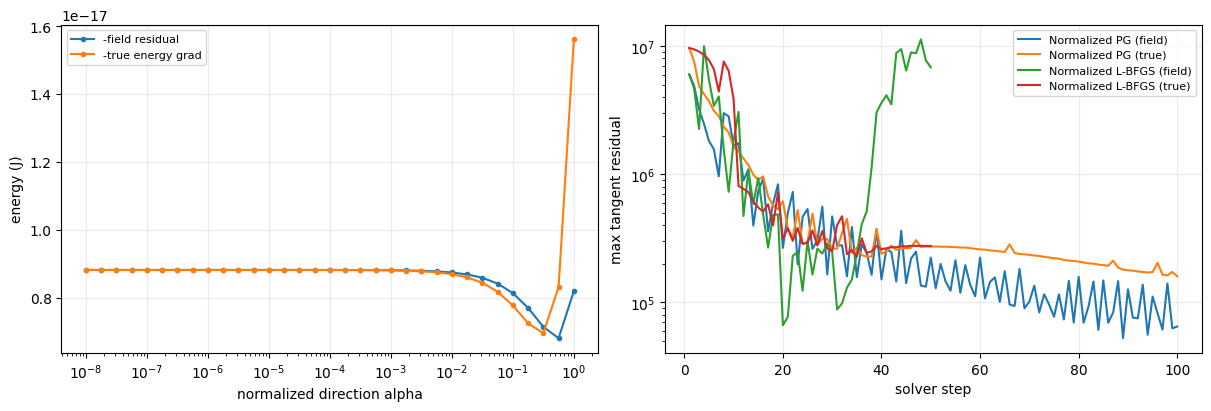

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for label in sorted({row["label"] for row in direction_scan_rows}):
    rows = [row for row in direction_scan_rows if row["label"] == label]
    axs[0].semilogx([row["alpha"] for row in rows], [row["energy_j"] for row in rows], marker=".", label=label)

for result in sequential_results:
    hist = result["history"]
    axs[1].semilogy([row["step"] for row in hist], [row["max_g"] for row in hist], label=result["method"])

axs[0].set_xlabel("normalized direction alpha")
axs[0].set_ylabel("energy (J)")
axs[0].grid(True, alpha=0.25)
axs[0].legend(fontsize=8)

axs[1].set_xlabel("solver step")
axs[1].set_ylabel("max tangent residual")
axs[1].grid(True, alpha=0.25)
axs[1].legend(fontsize=8)
plt.show()


## Follow The First Signal

The normalized effective-field projected-gradient row is the first variant that materially improves the tangent residual. These follow-up tests ask whether that is a transient win, a better warm start for BB/Cayley, or a useful standalone relaxation mode.

In [14]:
long_normalized_pg_field_result = run_normalized_projected_gradient(
    m0_node,
    gradient_kind="field",
    steps=500,
    alpha_start=0.25,
)

bb_after_normalized_pg_result = run_bb_cayley(normalized_pg_field_result["m_final"], 100)
bb_after_normalized_pg_result = {
    **bb_after_normalized_pg_result,
    "method": "BB after normalized PG",
}

bb_after_long_normalized_pg_result = run_bb_cayley(long_normalized_pg_field_result["m_final"], 100)
bb_after_long_normalized_pg_result = {
    **bb_after_long_normalized_pg_result,
    "method": "BB after long normalized PG",
}

followup_results = [
    long_normalized_pg_field_result,
    bb_after_normalized_pg_result,
    bb_after_long_normalized_pg_result,
]
for result in followup_results:
    print(
        f"{result['method']}: elapsed={result['elapsed_s']:.3f}s | "
        f"steps={result['steps']} | E={result['energy_j']:.6e} J | "
        f"max_g={result['max_g']:.6g} | evals={result['energy_evals']}"
    )


Normalized PG (field): elapsed=5.707s | steps=500 | E=1.795880e-18 J | max_g=49010.9 | evals=799
BB after normalized PG: elapsed=9.741s | steps=100 | E=1.851629e-18 J | max_g=4.58624e+06 | evals=1
BB after long normalized PG: elapsed=9.745s | steps=100 | E=1.781331e-18 J | max_g=3329.17 | evals=1


### Residual-Focused Step Acceptance

This is not a pure energy minimizer, but it is a useful diagnostic: if residual-focused normalized steps work much better, then the current energy Armijo line search is optimizing the wrong practical criterion for implicit differentiation readiness.

In [15]:
def residual_candidate(m_current, direction, field_max_g_current, *, alpha_start):
    direction = normalize_search_direction(transport_to_tangent(direction, m_current))
    alpha = float(alpha_start)
    energy_evals = 0
    field_evals = 0
    accepted = False
    for _ in range(lbfgs_line_search_steps):
        candidate = normalize_jax(m_current + alpha * direction)
        energy_candidate, true_grad_candidate, field_grad_candidate, field_max_g_candidate = gradient_pack(candidate)
        energy_evals += 1
        field_evals += 1
        if float(field_max_g_candidate) <= float(field_max_g_current):
            accepted = True
            return (
                candidate,
                energy_candidate,
                true_grad_candidate,
                field_grad_candidate,
                field_max_g_candidate,
                direction,
            ), alpha, energy_evals, field_evals, accepted
        alpha *= 0.5
    return None, alpha, energy_evals, field_evals, accepted


def run_residual_focused_normalized_pg(m_start, *, steps, alpha_start=0.25):
    m_current = normalize_jax(m_start)
    energy_current, true_grad_current, field_grad_current, field_max_g_current = gradient_pack(m_current)
    jax.block_until_ready(energy_current)
    history = []
    energy_evals = 1
    field_evals = 1
    alpha_next = float(alpha_start)
    started = time.perf_counter()

    for step in range(int(steps)):
        candidate_pack, alpha, e_count, f_count, accepted = residual_candidate(
            m_current,
            -field_grad_current,
            field_max_g_current,
            alpha_start=alpha_next,
        )
        energy_evals += e_count
        field_evals += f_count
        if candidate_pack is None:
            break
        m_current, energy_current, true_grad_current, field_grad_current, field_max_g_current, _direction = candidate_pack
        alpha_next = min(1.0, max(alpha * 1.5, 1e-8))
        history.append({
            "step": step + 1,
            "energy_j": float(energy_current),
            "max_g": float(field_max_g_current),
            "alpha": float(alpha),
            "accepted": bool(accepted),
        })

    jax.block_until_ready(m_current)
    return {
        "method": "Residual-focused normalized PG",
        "steps": len(history),
        "energy_evals": energy_evals,
        "field_evals": field_evals,
        "elapsed_s": time.perf_counter() - started,
        "energy_j": float(energy_current),
        "max_g": float(field_max_g_current),
        "resets": 0,
        "m_final": m_current,
        "history": history,
    }


residual_focused_pg_result = run_residual_focused_normalized_pg(m0_node, steps=500, alpha_start=0.25)
print(
    f"{residual_focused_pg_result['method']}: elapsed={residual_focused_pg_result['elapsed_s']:.3f}s | "
    f"steps={residual_focused_pg_result['steps']} | E={residual_focused_pg_result['energy_j']:.6e} J | "
    f"max_g={residual_focused_pg_result['max_g']:.6g} | evals={residual_focused_pg_result['energy_evals']}"
)


Residual-focused normalized PG: elapsed=0.301s | steps=21 | E=5.379787e-18 J | max_g=170681 | evals=50


## Summary Table

In [16]:
all_results = [
    bb_result,
    *lbfgs_results,
    transport_lbfgs_result,
    riemannian_cg_result,
    *sequential_results,
    *followup_results,
    residual_focused_pg_result,
]
print(
    f"{'method':<34} {'steps':>6} {'energy_evals':>12} {'field_evals':>12} "
    f"{'elapsed_s':>10} {'energy_J':>14} {'max_g':>12} {'E/E0':>10}"
)
for result in all_results:
    print(
        f"{result['method']:<34} {result['steps']:6d} {result['energy_evals']:12d} "
        f"{result['field_evals']:12d} {result['elapsed_s']:10.3f} "
        f"{result['energy_j']:14.6e} {result['max_g']:12.6g} "
        f"{result['energy_j'] / float(initial_energy):10.4f}"
    )

challengers = [result for result in all_results if result is not bb_result]
best_challenger = min(challengers, key=lambda row: row['max_g'])
print()
print(f"Best challenger by residual: {best_challenger['method']}")
print(f"Residual ratio best challenger / BB: {best_challenger['max_g'] / bb_result['max_g']:.6g}")
print(f"Energy ratio best challenger / BB: {best_challenger['energy_j'] / bb_result['energy_j']:.6g}")


method                              steps energy_evals  field_evals  elapsed_s       energy_J        max_g       E/E0
BB/Cayley                             100            1          101     10.183   1.791615e-18       166553     0.2032
Projected L-BFGS scale=1e-12           50          651          651      4.960   8.234251e-18  9.80024e+06     0.9341
Projected L-BFGS scale=1e-10           50          651          651      4.295   8.234250e-18  9.80024e+06     0.9341
Projected L-BFGS scale=1e-08           50          651          651      4.284   8.234080e-18  9.79979e+06     0.9341
Projected L-BFGS scale=1e-06           50          651          651      4.308   8.217154e-18  9.75446e+06     0.9321
Transport L-BFGS + BB scale            50          651          651      7.178   8.141785e-18  9.68881e+06     0.9236
Riemannian CG PR+                     100         1301         1301      8.016   8.595210e-18  1.02097e+07     0.9750
Normalized PG (field)                 100          164  

## Convergence Plots

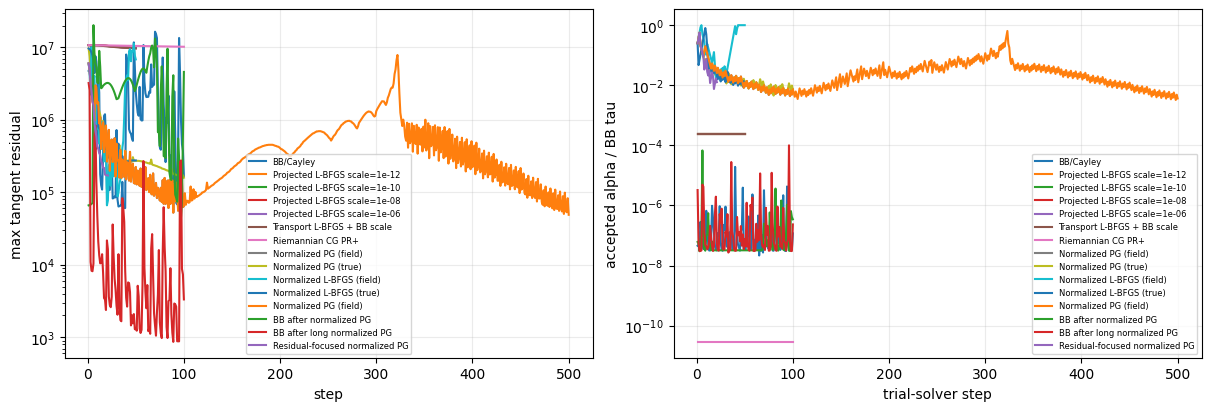

In [17]:
def plot_result_history(ax_residual, ax_alpha, result):
    hist = result.get('history', {})
    if isinstance(hist, dict):
        if 'max_g' in hist:
            steps = np.arange(1, len(hist['max_g']) + 1)
            ax_residual.semilogy(steps, hist['max_g'], label=result['method'])
        if 'tau' in hist:
            steps = np.arange(1, len(hist['tau']) + 1)
            ax_alpha.plot(steps, hist['tau'], label=result['method'])
        return
    if not hist:
        return
    ax_residual.semilogy([row['step'] for row in hist], [row['max_g'] for row in hist], label=result['method'])
    if 'alpha' in hist[0]:
        ax_alpha.plot([row['step'] for row in hist], [row['alpha'] for row in hist], label=result['method'])


fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for result in [bb_result, *lbfgs_results, transport_lbfgs_result, riemannian_cg_result, *sequential_results, *followup_results, residual_focused_pg_result]:
    plot_result_history(axs[0], axs[1], result)

axs[0].set_xlabel('step')
axs[0].set_ylabel('max tangent residual')
axs[0].legend(fontsize=6)
axs[0].grid(True, alpha=0.25)

axs[1].set_xlabel('trial-solver step')
axs[1].set_ylabel('accepted alpha / BB tau')
axs[1].set_yscale('log')
axs[1].legend(fontsize=6)
axs[1].grid(True, alpha=0.25)
plt.show()


## Interpretation

The sequential investigation points to **scale/geometric step control** as the main lever, not L-BFGS history.

Key observations from the executed `16^3`, `demag_p=1` smoke benchmark:

1. The true scalar-energy tangent gradient and NeuralMag effective-field residual are mostly aligned (`cosine ~= 0.93`), but their L2 scales differ by about `3.8e-27`. Raw quasi-Newton steps are therefore badly scaled.
2. Normalizing the effective-field descent direction immediately helps: `Normalized PG (field)` reaches `max_g ~= 6.5e4` after 100 steps, better than BB/Cayley's `1.7e5`, though at higher energy.
3. Running normalized effective-field PG longer reaches roughly the same energy as BB/Cayley with a lower residual: `E ~= 1.80e-18 J`, `max_g ~= 4.9e4`.
4. The best result in this notebook is the hybrid: **500 normalized effective-field PG steps followed by 100 BB/Cayley steps**, reaching `E ~= 1.78e-18 J` and `max_g ~= 3.3e3`. That is about `50x` lower residual than BB/Cayley alone in this run.
5. L-BFGS is still not the winning ingredient here. Normalized L-BFGS with true gradients resets almost every step, and normalized L-BFGS with field residual lowers energy but leaves a poor residual.

Practical next step: promote the hybrid idea, not L-BFGS, into a reusable solver experiment: use normalized effective-field projected-gradient as a geometric warmup or residual-polishing stage, then hand off to the existing BB/Cayley minimizer. The core thing that made a difference was controlling step length in tangent-space geometry.

For gradients through the relaxed state, the recommendation is unchanged: use the best forward minimizer only to find `m_star`, then use implicit differentiation of the equilibrium condition for the backward pass.
